# Rosenbrock — MCMC sampler sanity check

A minimal end-to-end sampling test on the classic Rosenbrock density, using `jax_fli`'s preconditioned-uniform reparameterisation and batched sampling — a quick correctness check before moving to full-field inference. Three samplers are run and compared at a matched gradient budget: NUTS (each stored draw is a full No-U-Turn trajectory, ~tens of gradient evaluations), unadjusted MCLMC (each kernel step is one integration step = 2 gradient evaluations, so the chain is thinned to match NUTS' per-draw budget), and MAMS (Metropolis-adjusted MCLMC — unbiased like NUTS, one quasi-random trajectory per draw). Success = the three posteriors agree on the banana, and the ESS-per-gradient table ranks the samplers sensibly.

In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "True"

from time import time

import arviz_base as azb
import arviz_stats as azs
import jax
import numpy as np
import numpyro

from jax_fli.infer import PreconditionnedUniform, analyze, batched_sampling, plot_posterior
from jax_fli.io import CatalogExtract

In [2]:
def rosenbrock_model(a=1.0, b=100.0):
    """
    Rosenbrock density bounded within a preconditioned Uniform space.
    """
    x = numpyro.sample("x", PreconditionnedUniform(low=-5.0, high=5.0))
    y = numpyro.sample("y", PreconditionnedUniform(low=-5.0, high=5.0))

    log_prob = -((a - x) ** 2 + b * (y - x**2) ** 2)

    numpyro.factor("rosenbrock_density", log_prob)

In [ ]:
key = jax.random.key(0)
num_warmup = 10000
num_samples = 2000
batch_count = 5
chain_count = 1

sampler_settings = {
    "NUTS": dict(target_accept=0.8, max_num_doublings=10),
    "MCLMC": dict(
        mclmc_desired_energy_var=1e-3,
        mclmc_init_step_size=1e-4,
        mclmc_diagonal_preconditioning=True,
        # 1 stored draw = 18 MCLMC steps (2 grad evals each) ~ 1 NUTS draw (~36 grad evals)
        thinning=18,
    ),
    # Metropolis-adjusted MCLMC (MAMS): unbiased, one quasi-random trajectory per stored draw
    "MAMS": dict(
        mams_target_accept=0.9,
        mclmc_init_step_size=1e-2,
        mclmc_diagonal_preconditioning=True,
    ),
}

for sampler, settings in sampler_settings.items():
    path = f"rosenbrock_samples_{sampler.lower()}"
    for i in range(chain_count):
        print(f"Running {sampler} chain {i}...")
        start = time()
        chain_key = jax.random.fold_in(key, i)
        batched_sampling(
            rosenbrock_model,
            path=f"{path}/chain_{i}",
            rng_key=chain_key,
            num_warmup=num_warmup,
            num_samples=num_samples,
            batch_count=batch_count,
            sampler=sampler,
            progress_bar=True,
            **settings,
        )
        print(f"Chain {i} completed in {time() - start:.2f} seconds.")

Running NUTS chain 0...


Found existing sampling state, skipping warmup compilation...
All 5 batches already completed. Exiting.
Chain 0 completed in 2.08 seconds.
Running MCLMC chain 0...


Found existing sampling state, skipping warmup compilation...


All 5 batches already completed. Exiting.
Chain 0 completed in 0.27 seconds.
Running MAMS chain 0...
Found existing sampling state, skipping warmup compilation...


All 5 batches already completed. Exiting.
Chain 0 completed in 0.27 seconds.


In [4]:
def load_chains(sampler):
    chains = {}
    for i in range(chain_count):
        files = [
            f"rosenbrock_samples_{sampler.lower()}/chain_{i}/samples/samples_batch_{j}.npz" for j in range(batch_count)
        ]
        samples = [dict(np.load(f)) for f in files]
        chains[f"chain_{i}"] = jax.tree.map(lambda *x: np.concatenate(x, axis=0)[None, ...], *samples)
    return jax.tree.map(lambda *x: np.concatenate(x, axis=0), *chains.values())


all_samples = {sampler: load_chains(sampler) for sampler in sampler_settings}

In [5]:
for sampler, samples in all_samples.items():
    print(f"── {sampler} ──")
    az_data = azb.from_dict({"posterior": samples})
    display(azs.summary(az_data))

── NUTS ──


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,0.97,0.65,-0.13,2,1280,1276,NaN,0.018,0.012
y,1.35,1.23,0.011,3.8,1236,1279,NaN,0.037,0.026


── MCLMC ──


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,0.95,0.66,-0.15,2,1517,1594,NaN,0.017,0.011
y,1.34,1.25,0.014,3.9,1691,1598,NaN,0.033,0.024


── MAMS ──


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
x,0.9,0.65,-0.18,1.9,655,473,NaN,0.023,0.015
y,1.2,1.16,0.0029,3.6,630,465,NaN,0.053,0.042


In [6]:
import re

from blackjax.diagnostics import effective_sample_size


def grads_per_draw(sampler):
    """Gradient evaluations per stored draw, read from the run's metrics.md."""
    text = open(f"rosenbrock_samples_{sampler.lower()}/chain_0/metrics.md").read()
    avg_steps = [float(m) for m in re.findall(r"\| \d+ \| ([\d.]+) \|", text)]
    if sampler == "NUTS":
        return float(np.mean(avg_steps))  # 1 gradient per leapfrog step
    if sampler == "MAMS":
        return 2.0 * float(np.mean(avg_steps))  # isokinetic mclachlan: 2 gradients per step
    return 2.0 * sampler_settings["MCLMC"]["thinning"]  # MCLMC: 2 gradients per thinned kernel step


total_draws = num_samples * batch_count * chain_count
print(f"{'sampler':8s} {'draws':>7s} {'grads':>10s} {'min ESS':>9s} {'ESS / 1k grads':>15s}")
for sampler, samples in all_samples.items():
    ess = {name: float(effective_sample_size(arr)) for name, arr in samples.items()}
    total_grads = grads_per_draw(sampler) * total_draws
    min_ess = min(ess.values())
    print(f"{sampler:8s} {total_draws:7d} {total_grads:10.0f} {min_ess:9.0f} {1000.0 * min_ess / total_grads:15.2f}")

sampler    draws      grads   min ESS  ESS / 1k grads


NUTS       10000     362400      1127            3.11


MCLMC      10000     360000      1462            4.06


MAMS       10000     437600       475            1.08


Removed no burn in
Removed no burn in
Removed no burn in


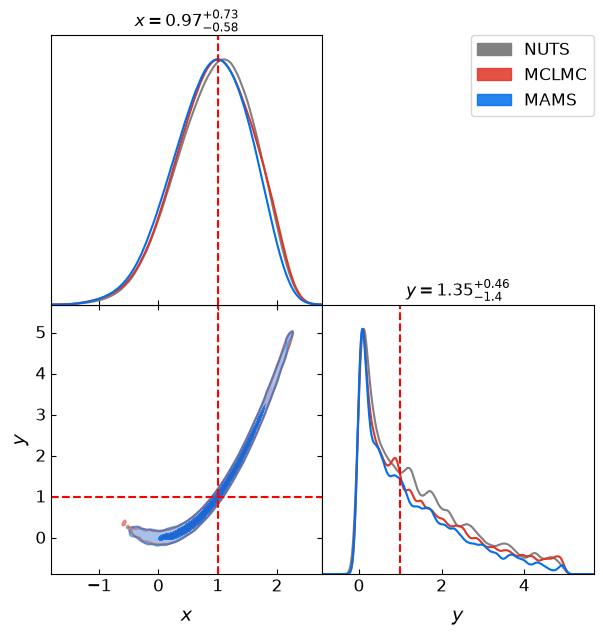

In [7]:
extracts = [
    CatalogExtract(name=sampler, cosmo=samples, truth_cosmo={"x": 1.0, "y": 1.0})
    for sampler, samples in all_samples.items()
]
plot_posterior(extracts)

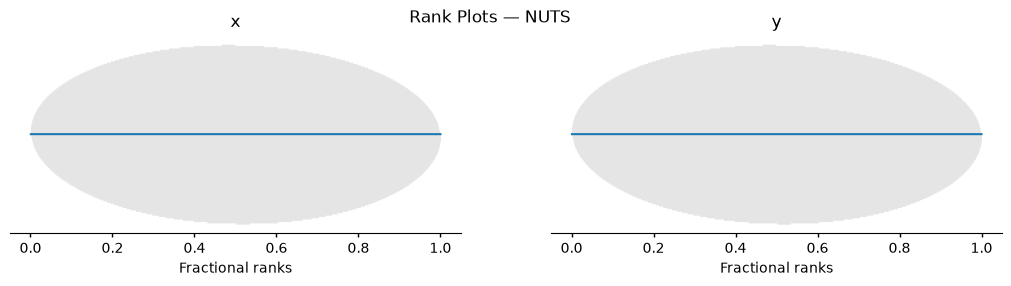

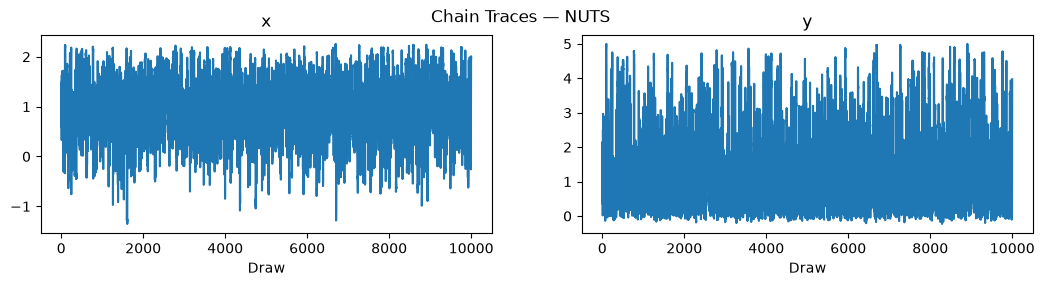

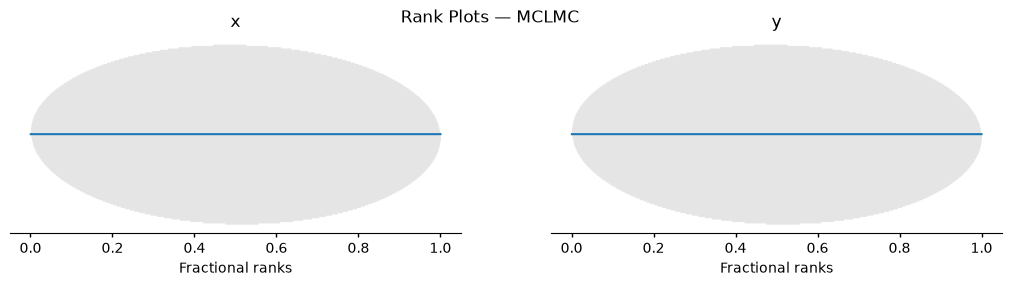

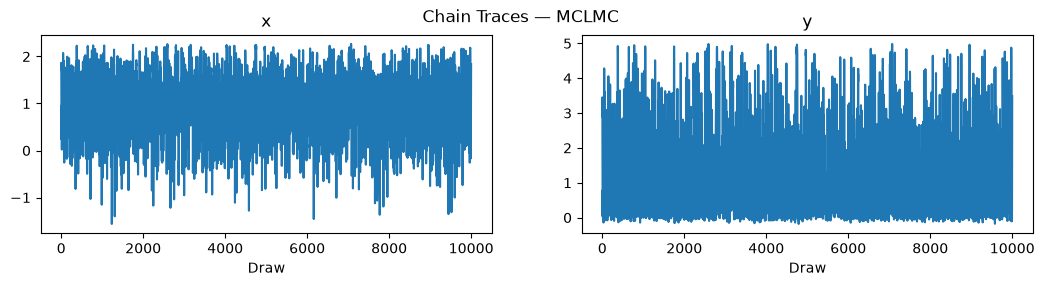

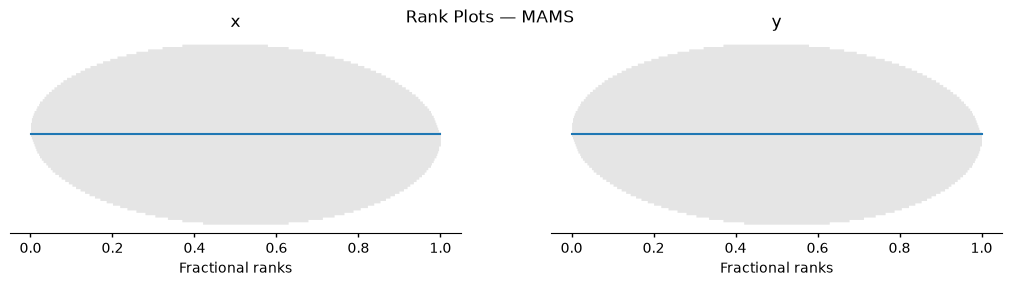

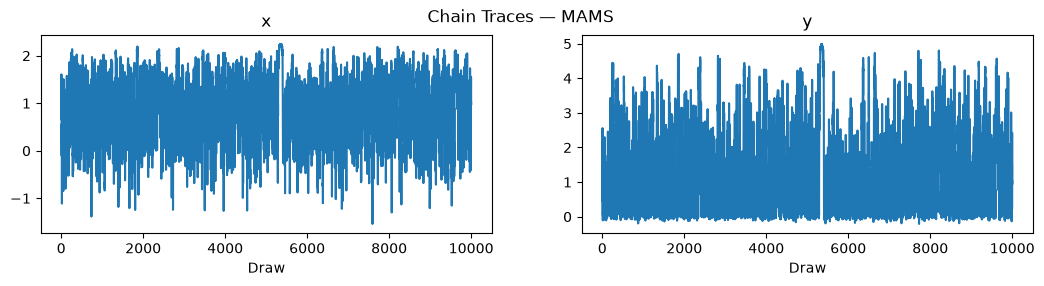

       mean        sd    ess_bulk  r_hat
x  0.898677  0.645425  655.300787    NaN
y  1.223972  1.162273  630.004122    NaN


In [8]:
analyze(extracts)